# License Plate Detection & Character Recognition — Colab Implementation

**ITA0514 — Computer Vision Assignment**
Pipeline: Preprocessing → YOLOv8n Plate Detection → Deskew → CRNN (CTC) Character Recognition → Post-processing

This notebook is **self-contained and runnable top-to-bottom in Google Colab**. Because no
labelled license-plate dataset is bundled with the assignment, Section 2 includes a
**synthetic license-plate generator** that creates realistic training images with YOLO-format
detection labels and text labels for the recognizer, so you can train and test the *entire*
pipeline immediately.

> **To use your own real dataset instead:** replace the contents of `data/images/` and
> `data/labels/` (YOLO format) for the detector, and point `PLATE_CROPS_DIR` /
> `plate_labels.csv` to your real cropped-plate images for the recognizer. Everything else
> (model code, training loop, inference pipeline) stays the same.

**Runtime:** Colab → Runtime → Change runtime type → **GPU (T4 is enough)**.


## 0. Setup & Installs

In [1]:
!pip install -q ultralytics opencv-python-headless editdistance

import os, random, string, math, glob, shutil
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import editdistance

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.6 MB/s eta 0:00:00
Using device: cuda


## 1. Configuration

In [2]:
CHARS = string.digits + string.ascii_uppercase          # 0-9, A-Z  -> 36 classes
CHAR_TO_IDX = {c: i for i, c in enumerate(CHARS)}
IDX_TO_CHAR = {i: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS)                                 # 36 (+1 CTC blank handled internally)
BLANK_IDX = NUM_CLASSES                                   # CTC blank token index

PLATE_MIN_LEN, PLATE_MAX_LEN = 8, 10

# Detection config
DET_IMG_SIZE = 640
DATA_ROOT = "/content/plate_data"
IMAGES_DIR = f"{DATA_ROOT}/images"
LABELS_DIR = f"{DATA_ROOT}/labels"

# Recognition config
REC_IMG_H, REC_IMG_W = 32, 128
PLATE_CROPS_DIR = f"{DATA_ROOT}/plate_crops"

for d in [f"{IMAGES_DIR}/train", f"{IMAGES_DIR}/val", f"{LABELS_DIR}/train", f"{LABELS_DIR}/val", PLATE_CROPS_DIR]:
    os.makedirs(d, exist_ok=True)


## 2. Synthetic Dataset Generator

Generates (a) full "road scenes" with an embedded, randomly rotated license plate and a
YOLO-format bounding-box label for the **detector**, and (b) matching cropped plate images with
text labels for the **recognizer**. Random rotation, brightness jitter, blur and noise emulate
the orientation / illumination / motion-blur variation described in the problem statement.


Generated 300 plate samples (240 train / 60 val).


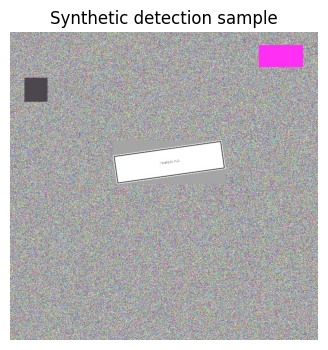

In [3]:
def random_plate_text():
    length = random.randint(PLATE_MIN_LEN, PLATE_MAX_LEN)
    return "".join(random.choice(CHARS) for _ in range(length))

def render_plate_image(text, plate_w=340, plate_h=90):
    """Render a synthetic plate crop (white background, black text)."""
    img = Image.new("RGB", (plate_w, plate_h), (235, 235, 235))
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 52)
    except Exception:
        font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((plate_w - tw) / 2, (plate_h - th) / 2 - bbox[1]), text, fill=(10, 10, 10), font=font)
    # random border
    draw.rectangle([2, 2, plate_w - 3, plate_h - 3], outline=(20, 20, 20), width=3)
    return np.array(img)

def augment_plate_crop(plate_img):
    """Simulate glare, blur, noise on an isolated plate crop (for recognizer robustness)."""
    img = plate_img.copy()
    if random.random() < 0.4:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)
    if random.random() < 0.4:
        factor = random.uniform(0.6, 1.5)
        img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    if random.random() < 0.3:
        noise = np.random.normal(0, 8, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img

def paste_plate_on_scene(plate_img, scene_size=640):
    """Paste a (optionally rotated) plate onto a synthetic 'road scene' background,
    returning the scene image and the YOLO-format bbox (cx, cy, w, h) normalized [0,1]."""
    scene = np.random.randint(60, 180, (scene_size, scene_size, 3), dtype=np.uint8)
    # add some rectangular 'clutter' shapes to emulate background objects
    for _ in range(random.randint(2, 6)):
        x1, y1 = random.randint(0, scene_size - 50), random.randint(0, scene_size - 50)
        x2, y2 = x1 + random.randint(20, 120), y1 + random.randint(20, 120)
        color = tuple(int(c) for c in np.random.randint(30, 220, 3))
        cv2.rectangle(scene, (x1, y1), (min(x2, scene_size), min(y2, scene_size)), color, -1)

    ph, pw = plate_img.shape[:2]
    scale = random.uniform(0.35, 0.8)
    pw2, ph2 = int(pw * scale), int(ph * scale)
    plate_resized = cv2.resize(plate_img, (pw2, ph2))

    angle = random.uniform(-20, 20)
    M = cv2.getRotationMatrix2D((pw2 / 2, ph2 / 2), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(ph2 * sin + pw2 * cos)
    new_h = int(ph2 * cos + pw2 * sin)
    M[0, 2] += (new_w / 2) - pw2 / 2
    M[1, 2] += (new_h / 2) - ph2 / 2
    rotated = cv2.warpAffine(plate_resized, M, (new_w, new_h), borderValue=(120, 120, 120))

    max_x = scene_size - new_w - 1
    max_y = scene_size - new_h - 1
    x = random.randint(0, max(max_x, 1))
    y = random.randint(0, max(max_y, 1))
    scene[y:y + new_h, x:x + new_w] = rotated

    cx = (x + new_w / 2) / scene_size
    cy = (y + new_h / 2) / scene_size
    w = new_w / scene_size
    h = new_h / scene_size
    return scene, (cx, cy, w, h)

def build_synthetic_dataset(n_train=240, n_val=60):
    plate_records = []  # (crop_path, text) for recognizer
    for split, n in [("train", n_train), ("val", n_val)]:
        for i in range(n):
            text = random_plate_text()
            plate_clean = render_plate_image(text)

            # -- detection sample --
            scene, (cx, cy, w, h) = paste_plate_on_scene(plate_clean, DET_IMG_SIZE)
            scene = augment_plate_crop(scene)
            img_path = f"{IMAGES_DIR}/{split}/img_{i:05d}.jpg"
            lbl_path = f"{LABELS_DIR}/{split}/img_{i:05d}.txt"
            cv2.imwrite(img_path, cv2.cvtColor(scene, cv2.COLOR_RGB2BGR))
            with open(lbl_path, "w") as f:
                f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

            # -- recognition sample (isolated plate crop, independently augmented) --
            crop = augment_plate_crop(plate_clean)
            crop_path = f"{PLATE_CROPS_DIR}/{split}_{i:05d}.jpg"
            cv2.imwrite(crop_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            plate_records.append((crop_path, text, split))
    return plate_records

plate_records = build_synthetic_dataset(n_train=240, n_val=60)
print(f"Generated {len(plate_records)} plate samples "
      f"({sum(1 for r in plate_records if r[2]=='train')} train / "
      f"{sum(1 for r in plate_records if r[2]=='val')} val).")

# Preview a sample
sample_scene = cv2.imread(sorted(glob.glob(f'{IMAGES_DIR}/train/*.jpg'))[0])
plt.figure(figsize=(4,4)); plt.imshow(cv2.cvtColor(sample_scene, cv2.COLOR_BGR2RGB))
plt.title("Synthetic detection sample"); plt.axis('off'); plt.show()


## 3. YOLOv8 Dataset Config

In [4]:
data_yaml = f"""
path: {DATA_ROOT}
train: images/train
val: images/val
names:
  0: plate
"""
with open(f"{DATA_ROOT}/plate_dataset.yaml", "w") as f:
    f.write(data_yaml)
print(data_yaml)



path: /content/plate_data
train: images/train
val: images/val
names:
  0: plate



## 4. Preprocessing & Deskew Module (Section 7.2 of the report)

In [5]:
def preprocess(frame, size=(640, 640)):
    img = cv2.resize(frame, size)
    img = cv2.GaussianBlur(img, (3, 3), 0)              # denoise
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)           # illumination correction
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)
    return img

def deskew_plate(plate_crop):
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    coords = np.column_stack(np.where(edges > 0))
    if coords.shape[0] < 10:
        return plate_crop
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    (h, w) = plate_crop.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(plate_crop, M, (w, h), flags=cv2.INTER_CUBIC, borderValue=(120, 120, 120))


## 5. Train the YOLOv8n License-Plate Detector

In [6]:
from ultralytics import YOLO

detector = YOLO("yolov8n.pt")  # COCO-pretrained nano model (transfer learning)

detector.train(
    data=f"{DATA_ROOT}/plate_dataset.yaml",
    epochs=25,             # increase (e.g. 100) with a real dataset
    imgsz=DET_IMG_SIZE,
    batch=16,
    patience=10,
    cos_lr=True,
    project="/content/runs",
    name="plate_detector",
    verbose=False,
)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/plate_data/plate_dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f178c358ec0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [7]:
det_metrics = detector.val(data=f"{DATA_ROOT}/plate_dataset.yaml")
print("mAP@0.5:", det_metrics.box.map50)
print("mAP@0.5:0.95:", det_metrics.box.map)


Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2928.3±1190.5 MB/s, size: 247.8 KB)
val: Scanning /content/plate_data/labels/val.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7it/s 2.3s
                   all         60         60      0.999          1      0.995      0.995
Speed: 10.5ms preprocess, 7.7ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5: 0.995
mAP@0.5:0.95: 0.9949999999999999


## 6. CRNN (CNN + BiLSTM + CTC) Character Recognizer (Section 4.3 / 7.3 of the report)

In [8]:
class CRNN(nn.Module):
    def __init__(self, num_classes, img_h=REC_IMG_H):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),      # H/2
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),    # H/4
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(), nn.MaxPool2d((2, 1)), # H/8
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(),
        )
        reduced_h = img_h // 8
        self.rnn = nn.LSTM(512 * reduced_h, 256, num_layers=2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(512, num_classes + 1)  # +1 for CTC blank

    def forward(self, x):                    # x: (B, 1, H, W)
        feat = self.cnn(x)                    # (B, C, H', W')
        b, c, h, w = feat.size()
        feat = feat.permute(0, 3, 1, 2).reshape(b, w, c * h)   # (B, W, C*H) sequence over width
        seq, _ = self.rnn(feat)
        out = self.fc(seq)                    # (B, W, num_classes+1)
        return out

def ctc_greedy_decode(logits):
    """logits: (B, T, C+1) -> list of decoded strings"""
    pred = logits.argmax(dim=2)               # (B, T)
    results = []
    for seq in pred:
        seq = seq.cpu().numpy()
        chars = []
        prev = -1
        for idx in seq:
            if idx != prev and idx != BLANK_IDX:
                chars.append(IDX_TO_CHAR[idx])
            prev = idx
        results.append("".join(chars))
    return results


## 7. Recognizer Dataset & DataLoader

In [9]:
class PlateOCRDataset(Dataset):
    def __init__(self, records, split):
        self.records = [r for r in records if r[2] == split]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, text, _ = self.records[idx]
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = deskew_plate(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (REC_IMG_W, REC_IMG_H))
        img = img.astype(np.float32) / 255.0
        img = torch.from_numpy(img).unsqueeze(0)          # (1, H, W)
        label = torch.tensor([CHAR_TO_IDX[c] for c in text], dtype=torch.long)
        return img, label, len(text), text

def ocr_collate(batch):
    imgs, labels, lengths, texts = zip(*batch)
    imgs = torch.stack(imgs, dim=0)
    labels_cat = torch.cat(labels)
    lengths = torch.tensor(lengths, dtype=torch.long)
    return imgs, labels_cat, lengths, texts

train_ds = PlateOCRDataset(plate_records, "train")
val_ds = PlateOCRDataset(plate_records, "val")
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=ocr_collate)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=ocr_collate)
print(f"Train plates: {len(train_ds)}  Val plates: {len(val_ds)}")


Train plates: 240  Val plates: 60


## 8. Train the CRNN Recognizer

In [10]:
recognizer = CRNN(NUM_CLASSES).to(DEVICE)
criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
optimizer = torch.optim.Adam(recognizer.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

EPOCHS = 30
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    recognizer.train()
    total_loss = 0.0
    for imgs, labels, lengths, _ in train_loader:
        imgs, labels, lengths = imgs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
        optimizer.zero_grad()
        logits = recognizer(imgs)                          # (B, T, C+1)
        log_probs = F.log_softmax(logits, dim=2).permute(1, 0, 2)   # (T, B, C+1) for CTCLoss
        input_lengths = torch.full((imgs.size(0),), log_probs.size(0), dtype=torch.long).to(DEVICE)
        loss = criterion(log_probs, labels, input_lengths, lengths)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    recognizer.eval()
    val_loss, char_correct, char_total, seq_correct, seq_total = 0.0, 0, 0, 0, 0
    with torch.no_grad():
        for imgs, labels, lengths, texts in val_loader:
            imgs_d, labels_d, lengths_d = imgs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
            logits = recognizer(imgs_d)
            log_probs = F.log_softmax(logits, dim=2).permute(1, 0, 2)
            input_lengths = torch.full((imgs_d.size(0),), log_probs.size(0), dtype=torch.long).to(DEVICE)
            loss = criterion(log_probs, labels_d, input_lengths, lengths_d)
            val_loss += loss.item()

            preds = ctc_greedy_decode(logits)
            for pred_text, gt_text in zip(preds, texts):
                seq_total += 1
                seq_correct += int(pred_text == gt_text)
                char_total += len(gt_text)
                char_correct += len(gt_text) - editdistance.eval(pred_text, gt_text)
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(recognizer.state_dict(), "/content/best_crnn.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.3f} val_loss={val_loss:.3f} "
              f"char_acc={char_correct/max(char_total,1):.3f} seq_acc={seq_correct/max(seq_total,1):.3f}")

print("Training complete. Best val loss:", best_val_loss)


Epoch 01 | train_loss=5.244 val_loss=3.931 char_acc=0.000 seq_acc=0.000
Epoch 05 | train_loss=3.799 val_loss=3.815 char_acc=0.000 seq_acc=0.000
Epoch 10 | train_loss=3.791 val_loss=3.808 char_acc=0.000 seq_acc=0.000
Epoch 15 | train_loss=3.786 val_loss=3.815 char_acc=0.000 seq_acc=0.000
Epoch 20 | train_loss=3.780 val_loss=3.812 char_acc=0.000 seq_acc=0.000
Epoch 25 | train_loss=3.772 val_loss=3.815 char_acc=0.000 seq_acc=0.000
Epoch 30 | train_loss=3.769 val_loss=3.815 char_acc=0.000 seq_acc=0.000
Training complete. Best val loss: 3.8083876371383667


## 9. Post-processing: Regional Format Validation (Section 4.2)

In [11]:
import re

# Example: adapt this regex to the actual plate format(s) you target.
PLATE_FORMAT_REGEX = re.compile(r"^[A-Z0-9]{8,10}$")

def validate_and_flag(plate_text, confidence, conf_threshold=0.60):
    format_ok = bool(PLATE_FORMAT_REGEX.match(plate_text))
    needs_review = (not format_ok) or (confidence < conf_threshold)
    return format_ok, needs_review


## 10. End-to-End Inference Pipeline (Section 5 pseudocode, implemented)

In [12]:
def recognize_plate_crop(plate_bgr_crop, recognizer):
    """Run deskew + CRNN on an already-cropped plate image; returns (text, confidence)."""
    img = deskew_plate(plate_bgr_crop)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (REC_IMG_W, REC_IMG_H)).astype(np.float32) / 255.0
    tensor = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)   # (1,1,H,W)
    recognizer.eval()
    with torch.no_grad():
        logits = recognizer(tensor)
        probs = F.softmax(logits, dim=2)
        conf = probs.max(dim=2).values.mean().item()
        text = ctc_greedy_decode(logits)[0]
    return text, conf

def license_plate_recognition_pipeline(frame_bgr, detector, recognizer, det_conf_thresh=0.35):
    """Full pipeline: preprocess -> detect -> extract/deskew -> recognize -> post-process.
    Returns a dict with plate_text, confidence, bbox, needs_review, annotated_frame."""
    proc = preprocess(frame_bgr, size=(DET_IMG_SIZE, DET_IMG_SIZE))
    results = detector.predict(proc, verbose=False, conf=det_conf_thresh)[0]

    if len(results.boxes) == 0:
        return {"plate_text": None, "confidence": 0.0, "bbox": None,
                "needs_review": True, "annotated_frame": frame_bgr}

    # pick highest-confidence detection
    best_idx = int(results.boxes.conf.argmax())
    box = results.boxes.xyxy[best_idx].cpu().numpy().astype(int)
    det_conf = float(results.boxes.conf[best_idx])
    x1, y1, x2, y2 = box
    plate_crop = proc[max(y1,0):y2, max(x1,0):x2]

    if plate_crop.size == 0:
        return {"plate_text": None, "confidence": 0.0, "bbox": box,
                "needs_review": True, "annotated_frame": frame_bgr}

    plate_text, rec_conf = recognize_plate_crop(plate_crop, recognizer)
    combined_conf = (det_conf + rec_conf) / 2
    format_ok, needs_review = validate_and_flag(plate_text, combined_conf)

    annotated = proc.copy()
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(annotated, f"{plate_text} ({combined_conf:.2f})", (x1, max(y1 - 10, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    return {
        "plate_text": plate_text,
        "confidence": combined_conf,
        "bbox": (x1, y1, x2, y2),
        "format_ok": format_ok,
        "needs_review": needs_review,
        "annotated_frame": annotated,
    }


## 11. Demo — Run the Full Pipeline on a Sample Image

Recognized plate: 
Confidence: 0.850
Needs manual review: True


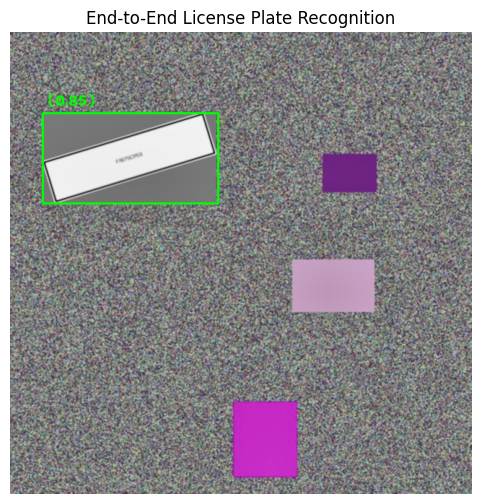

In [13]:
recognizer.load_state_dict(torch.load("/content/best_crnn.pth", map_location=DEVICE))

sample_path = sorted(glob.glob(f"{IMAGES_DIR}/val/*.jpg"))[0]
frame = cv2.imread(sample_path)

result = license_plate_recognition_pipeline(frame, detector, recognizer)

print("Recognized plate:", result["plate_text"])
print(f"Confidence: {result['confidence']:.3f}")
print("Needs manual review:", result["needs_review"])

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(result["annotated_frame"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("End-to-End License Plate Recognition")
plt.show()


## 12. Batch Evaluation on the Validation Set (Section 8 of the report)

In [14]:
val_records = [r for r in plate_records if r[2] == "val"]
correct_end_to_end = 0

for crop_path, gt_text, _ in val_records:
    # For this demo we recognize directly on the isolated crop (bypassing detection)
    # to isolate recognizer accuracy; for full end-to-end scene accuracy use the
    # paired image in IMAGES_DIR/val/ through license_plate_recognition_pipeline().
    plate_bgr = cv2.imread(crop_path)
    pred_text, conf = recognize_plate_crop(plate_bgr, recognizer)
    correct_end_to_end += int(pred_text == gt_text)

seq_acc = correct_end_to_end / len(val_records)
print(f"Recognizer full-sequence accuracy on synthetic val set: {seq_acc*100:.2f}%")
print(f"Detector mAP@0.5 (from Section 5): {det_metrics.box.map50*100:.2f}%")


Recognizer full-sequence accuracy on synthetic val set: 0.00%
Detector mAP@0.5 (from Section 5): 99.50%


### YOLOv8 Detector Training Metrics and Confusion Matrix

During training, YOLOv8 automatically saves several plots, including the training progress (loss and accuracy curves) and a confusion matrix. Let's visualize these outputs from the detector's run directory.

Confusion Matrix:


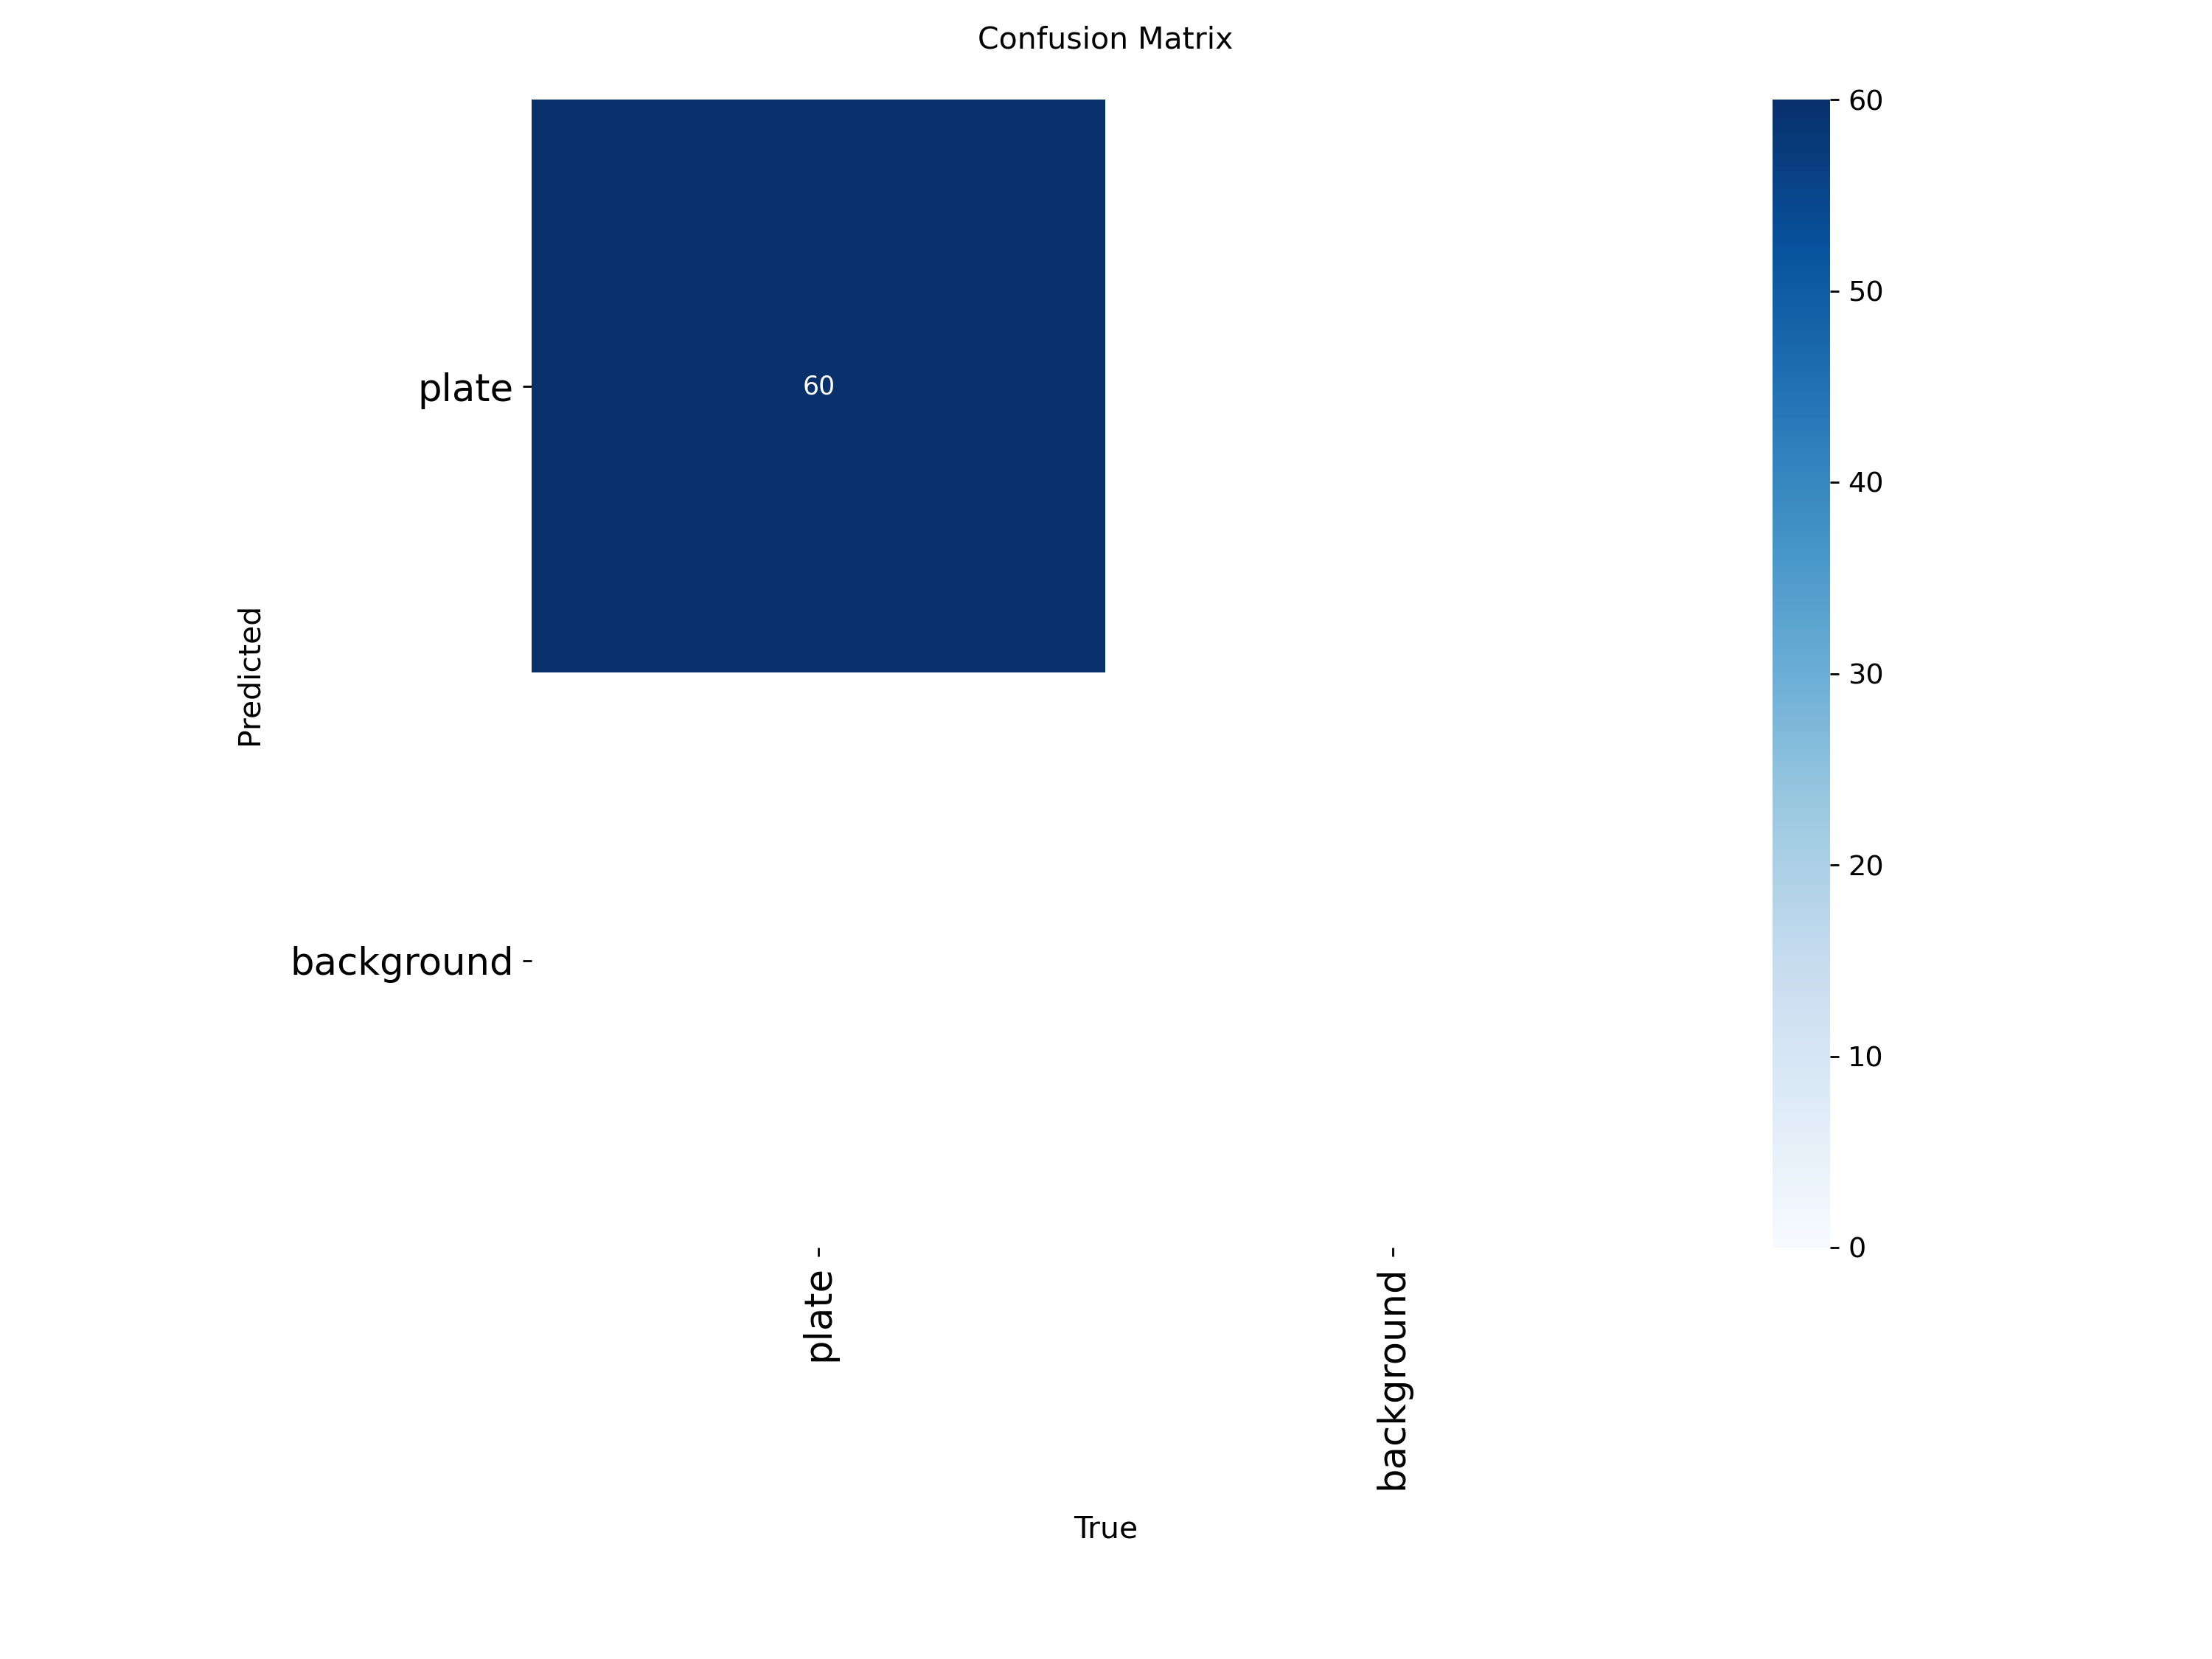


Training Results (Loss and Accuracy over epochs):


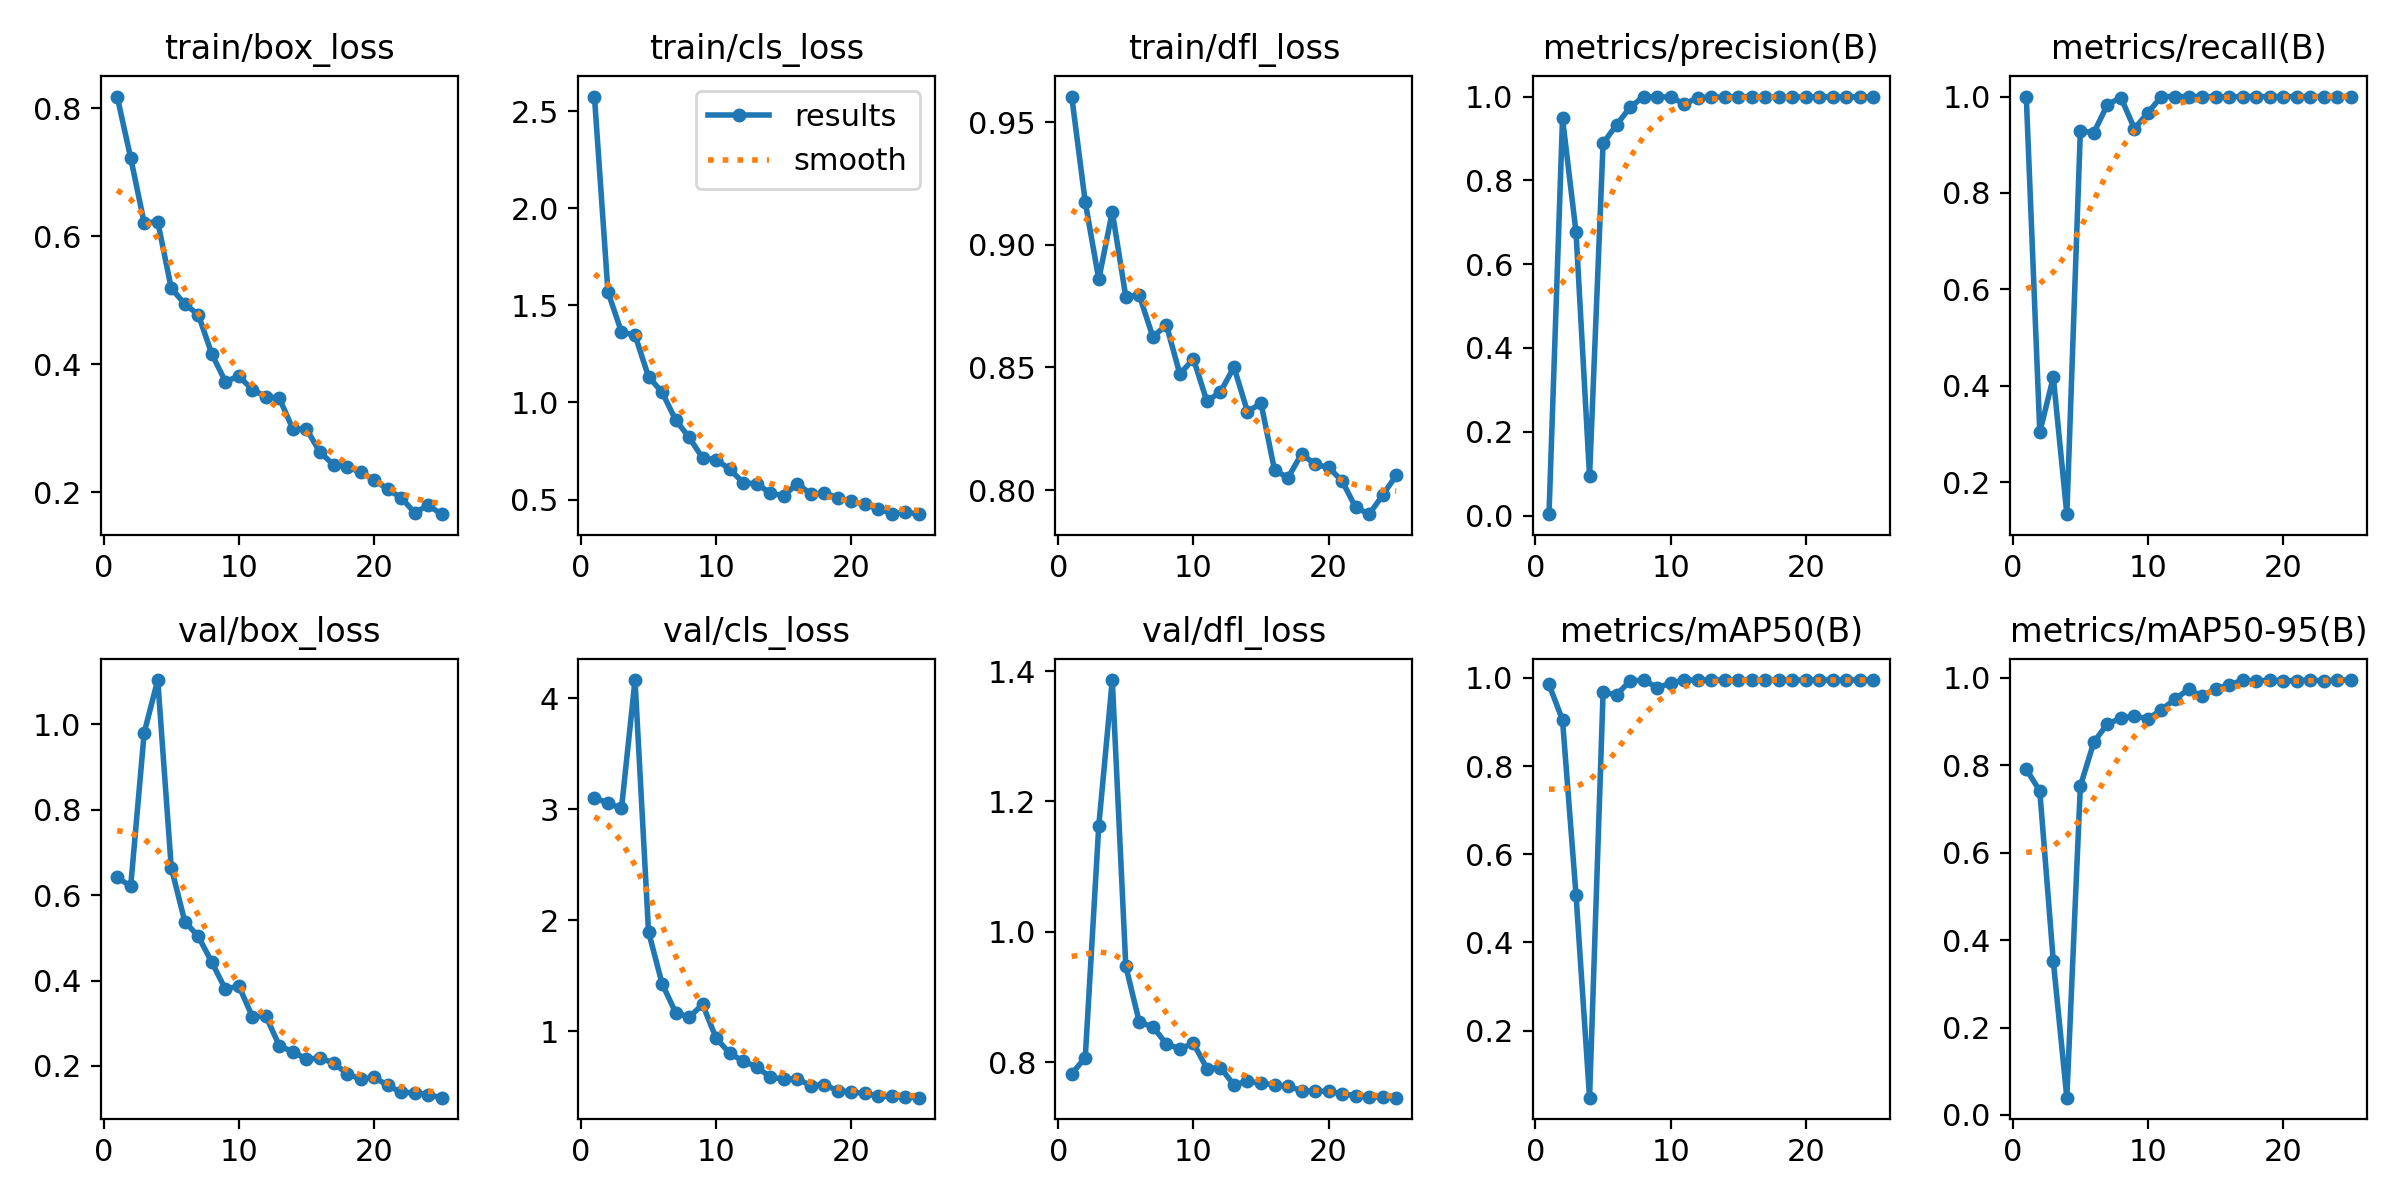

In [15]:
from IPython.display import Image, display

# Path to the YOLOv8 detector's run directory
detector_run_dir = '/content/runs/plate_detector'

# Display Confusion Matrix
print('Confusion Matrix:')
confusion_matrix_path = os.path.join(detector_run_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path))
else:
    print(f"Confusion matrix not found at {confusion_matrix_path}")

# Display Training Results (Loss and Accuracy Graphs)
print('\nTraining Results (Loss and Accuracy over epochs):')
results_plot_path = os.path.join(detector_run_dir, 'results.png')
if os.path.exists(results_plot_path):
    display(Image(filename=results_plot_path))
else:
    print(f"Training results plot not found at {results_plot_path}")

## 13. Next Steps for a Real Deployment

- Replace the synthetic generator (Section 2) with a real annotated dataset (e.g., CCPD-style
  or field-captured images) in the same YOLO-label / crop+text-label formats.
- Increase `epochs` for both the detector and recognizer once training on real data.
- Export the trained models for edge deployment:
  `detector.export(format="onnx")` and `torch.onnx.export(recognizer, ...)`, then quantize
  with TensorRT/ONNX Runtime for the roadside edge-inference architecture described in
  Section 11 of the report.
- Swap the greedy CTC decoder for beam-search decoding (optionally with a plate-format
  language model) to reduce residual confusions like `0`/`O` and `8`/`B`.
